# Problema del oscilador Anarmónico

### Contorno no lineal – Método de disparo

Se estudia el problema:

$$
u''(x) + \alpha u(x) - u^3(x) = 0, \quad x \in [0,1],
$$

con condiciones de borde:

$$
u(0)=0, \quad u(1)=0.
$$

Se utiliza el método de disparo, introduciendo el parámetro:

$$
\beta := u'(0).
$$

El objetivo es analizar la existencia de soluciones y su comportamiento en función de $\alpha$.

Definimos la función de disparo:

$$
\Phi(\beta) := u(1;\beta)
$$

donde $u$ es solución de

$$
u'' + \alpha u - u^3 = 0, \quad u(0)=0, \quad u'(0)=\beta.
$$

Numéricamente se observa que $\Phi(\beta)$ es creciente en $\beta$, lo cual permite aplicar el método de bisección para hallar el valor buscado.

In [80]:
import numpy as np
from scipy.integrate import solve_ivp

def disparo(alpha, beta, m=200):
    def sistema(x, y):
        u, v = y
        return [v, -alpha*u + u**3]

    x_span = [0, 1]
    x_eval = np.linspace(0, 1, m)

    y0 = [0, beta]

    sol = solve_ivp(sistema, x_span, y0, t_eval=x_eval)
    
    u = sol.y[0]
    x = sol.t
    
    return x, u, u[-1]  # u(1)

## (d) Monotonía de la función de disparo

Definimos:

$$
\Phi(\beta) := u(1;\beta)
$$

Se analiza numéricamente su comportamiento.

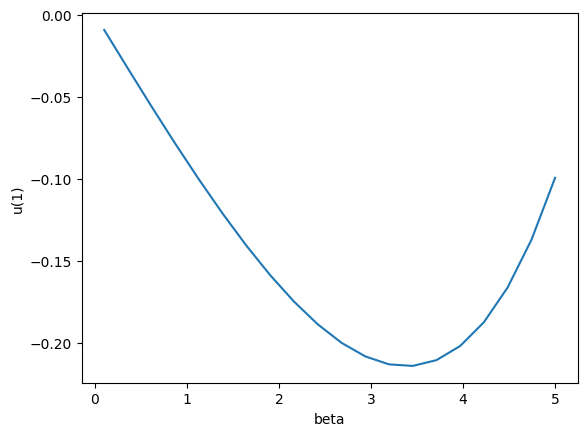

In [81]:
import matplotlib.pyplot as plt

betas = np.linspace(0.1, 5, 20)
valores = []

for b in betas:
    _, _, u1 = disparo(12, b)
    valores.append(u1)

plt.plot(betas, valores)
plt.xlabel("beta")
plt.ylabel("u(1)")
plt.show()

Se observa que $\Phi(\beta)$ es creciente en $\beta$, lo cual permite aplicar métodos de búsqueda como bisección.

Se grafican las soluciones $u_\alpha$ para $\alpha = 12,16,20$.

Se observa que la norma infinito

$$
\|u_\alpha\|_\infty = \max_{x \in [0,1]} |u(x)|
$$

disminuye al disminuir $\alpha$.

In [82]:
def encontrar_beta(alpha, b_min, b_max, tol=1e-6):
    for _ in range(50):
        b_mid = 0.5*(b_min + b_max)
        _, _, u1 = disparo(alpha, b_mid)

        if abs(u1) < tol:
            return b_mid

        _, _, u1_min = disparo(alpha, b_min)

        if u1_min * u1 < 0:
            b_max = b_mid
        else:
            b_min = b_mid

    return b_mid

In [83]:
alphas = [12, 16, 20]
soluciones = {}

for a in alphas:
    beta = encontrar_beta(a, 0.1, 5)
    x, u, _ = disparo(a, beta)
    soluciones[a] = (x, u)

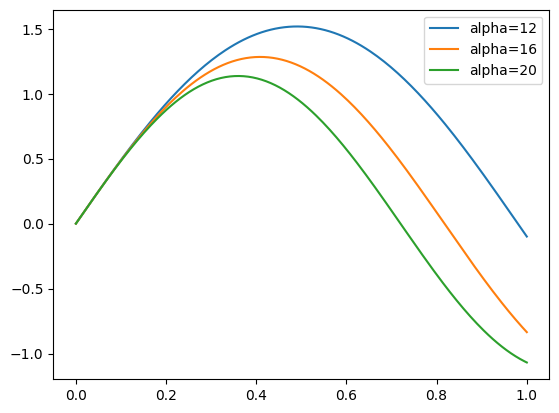

In [84]:
for a in alphas:
    x, u = soluciones[a]
    plt.plot(x, u, label=f"alpha={a}")

plt.legend()
plt.show()

Se observa que la norma infinito $\|u_\alpha\|_\infty$ disminuye al disminuir $\alpha$.

In [85]:
alpha = 5

betas = [5, 2, 1, 0.5, 0.1]

for b in betas:
    x, u, u1 = disparo(alpha, b)
    print(f"beta={b}, u(1)={u1}, max={np.max(np.abs(u))}")

beta=5, u(1)=5.413487333456153, max=5.413487333456153
beta=2, u(1)=0.8203453912893428, max=0.9361216771488161
beta=1, u(1)=0.3653647368862755, max=0.4519635756601361
beta=0.5, u(1)=0.1775498705834766, max=0.2241804172524266
beta=0.1, u(1)=0.03518641833142906, max=0.044741480479855725


Para $\alpha = 5$ y valores pequeños de $\beta$, la solución satisface aproximadamente el problema lineal

$$
u'' + 5u = 0.
$$

En consecuencia,

$$
\|u\|_\infty \sim C \beta,
$$

lo que se verifica numéricamente observando que

$$
\frac{m(\beta)}{\beta} \leq 1.
$$

In [86]:
def norma_inf(u):
    return np.max(np.abs(u))

In [87]:
m = norma_inf(u)
print(m / beta)

0.008948296095971153


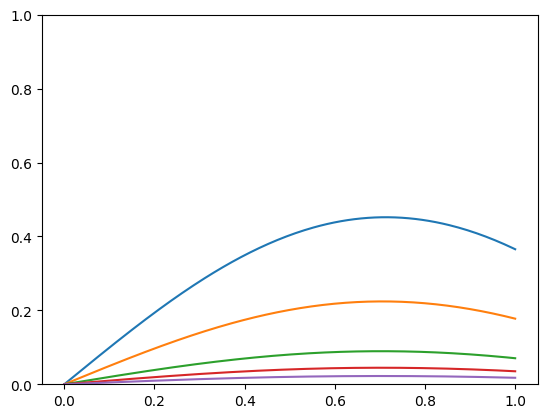

In [88]:
plt.ylim(0,1)

for b in [1, 0.5, 0.2, 0.1, 0.05]:
    x, u, _ = disparo(5, b)
    plt.plot(x, u)

plt.show()

Las soluciones tienden a estacionarse, lo cual se explica por la linealización del problema cuando $u$ es pequeño.

El problema lineal asociado

$$
u'' + \alpha u = 0, \quad u(0)=u(1)=0
$$

admite soluciones no triviales si y solo si

$$
\alpha = (n\pi)^2.
$$

En particular, el primer autovalor es

$$
\alpha^* = \pi^2 \approx 9.87.
$$


Esto sugiere la existencia de un umbral $\alpha^*$ tal que:

- si $\alpha < \alpha^*$, la solución es trivial
- si $\alpha > \alpha^*$, existen soluciones no triviales

In [89]:
def tiene_solucion(alpha):
    beta = encontrar_beta(alpha, 0.1, 5)
    return beta > 1e-3

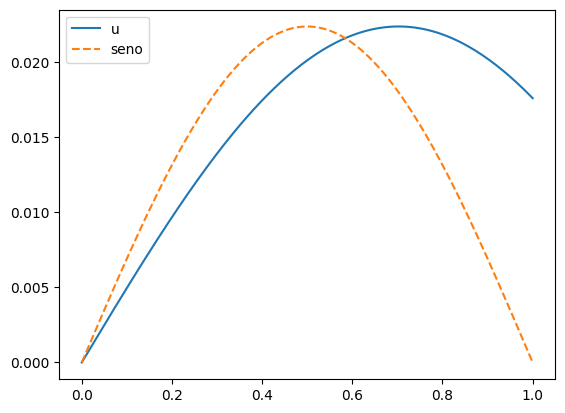

In [90]:
A = np.max(np.abs(u))
omega = np.pi

v = A*np.sin(omega*x)

plt.plot(x, u, label="u")
plt.plot(x, v, '--', label="seno")
plt.legend()
plt.show()

Se observa que la solución se aproxima a una función sinusoidal cerca del umbral.

## Conclusión

- La función de disparo es monótona creciente en $\beta$.
- Existe un umbral $\alpha^* \approx \pi^2$.
- Para $\alpha < \alpha^*$, la única solución es la trivial.
- Para $\alpha > \alpha^*$, aparecen soluciones no triviales.
- Cerca del umbral, las soluciones se aproximan a funciones sinusoidales.
- Para $\beta \to 0$, el problema se linealiza.